In [1]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(base_url="http://127.0.0.1:1234/v1", model="gemma-3-27b-it", api_key="random")

In [2]:
import asyncio

class Timer:
    def __init__(self, timeout, callback):
        self._timeout = timeout
        self._callback = callback
        self._task = asyncio.ensure_future(self._job())

    async def _job(self):
        await asyncio.sleep(self._timeout)
        await self._callback()

    def cancel(self):
        self._task.cancel()

In [3]:
class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    async def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        for tool_call in message.tool_calls:
            output = await self.tools_by_name[tool_call["name"]].ainvoke(
                tool_call["args"]
            )
            return output

In [4]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph

# Schema for structured output
from pydantic import BaseModel, Field

class KeyPriorities(BaseModel):
    destination: int = Field(1, description="Priority for destination (1 = non-negotiable, 5 = negligible)")
    num_adults: int = Field(1, description="Priority for number of adults (1 = non-negotiable, 5 = negligible)")
    num_children: int = Field(1, description="Priority for number of children in the strip (1 = non-negotiable, 5 = negligible)")
    from_date: int = Field(1, description="Priority for start date of trip (1 = non-negotiable, 5 = negligible)")
    to_date: int = Field(1, description="Priority for end date of trip (1 = non-negotiable, 5 = negligible)")
    num_rooms: int = Field(1, description="Priority for number of rooms (1 = non-negotiable, 5 = negligible)")
    amenities: int = Field(1, description="Priority for amenities required (1 = non-negotiable, 5 = negligible)")
    free_breakfast: int = Field(1, description="Priority for whether or not free breakfast required (1 = non-negotiable, 5 = negligible)")
    free_cancelation: int = Field(1, description="Priority for whether or not free cancelation required (1 = non-negotiable, 5 = negligible)")
    max_price: int = Field(1, description="Priority for the max budget (1 = non-negotiable, 5 = negligible)")

class HotelSearchRequirements(BaseModel):
    destination: str = Field(default=None, description="The destination where to look for hotels. N/A if empty")
    num_adults: int = Field(None, description="Number of Adults in the trip. -1 if empty")
    num_children: int = Field(None, description="Number of children in the strip. -1 if empty")
    from_date: str = Field(None, description="Start date of trip. N/A if empty")
    to_date: str = Field(None, description="End date of trip. This is the date till which they want to book the hotel. N/A if empty")
    num_rooms: int = Field(None, description="Number of rooms. -1 if empty")
    amenities: list[str] = Field(None, description="Amenities required.")
    free_breakfast: str = Field(None, description="Is free breakfast required? N/A if empty. Yes if free breakfast is required and No if free breakfast is not needed.")
    free_cancelation: str = Field(None, description="Is free cancelation required? N/A if empty. Yes if free cancelation is required and No if free cancelation is not needed.")
    max_price: float = Field(None, description="What is the max budget? -1 if empty")

model_with_output = model.with_structured_output(HotelSearchRequirements)

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    priorities: KeyPriorities
    users: dict[str, HotelSearchRequirements]
    input: str
    destination: str
    num_adults: str
    num_children: str
    from_date: str
    to_date: str
    num_rooms: str
    amenities: list
    free_breakfast: str
    free_cancelation: str
    max_price: str
    search_results: str
    is_init: bool
    extracted: str
    who: str
    ask_host_intervention: bool
    host: str
    is_nudge: bool

graph_builder = StateGraph(State)

In [5]:
# Schema for structured output
from pydantic import BaseModel, Field
import enum

class HotelAmenityDetail(BaseModel):
    icon: str = Field(None, description="Icon that visually represents an amenity.")
    name: str = Field(None, description="Name of the amenity.")
    tags: list[str] = Field(None, description="List of tags associated with the amenity.")

class HotelType(enum.Enum):
    STAY_NOW = 'STAY_NOW'
    ASI = 'ASI'
    SABRE = 'SABRE'
    SITE_MINDER = 'SITE_MINDER'
    CLOUDBEDS = 'CLOUDBEDS'

class HotelDetails(BaseModel):
    address: str = Field(None, description="Address of the hotel.")
    amenities: list[HotelAmenityDetail] = Field(None, description="List of amenities that the hotel provides.")
    code: str = Field(None, description="Unique code representing the hotel.")
    distance: float = Field(None, description="Distance from destination.")
    guestRating: float = Field(None, description="Guest rating of hotel.")
    hotelGroup: str = Field(None, description="Hotel Group that owns the hotel.")
    hotelType: HotelType
    intro: str = Field(None, description="An introduction about the hotel.")
    logo: str  = Field(None, description="Hotel's logo.")
    name: str = Field(None, description="The name of the hotel.")
    reviewsCount: int = Field(None, description="Count of how many people reviewed the hotel.")
    summary: str = Field(None, description="A summary describing the hotel.")


class HotelSearchResults(BaseModel):
    hotels: list[str] = Field(None, description="List of hotels that met the search requirements.")


    def render_as_string(self):
        string = ""
        for hotel in self.hotels:
            string += f"""
                Hotel Name: {hotel["name"]}
                Summary: {hotel["summary"]}
            """

        if len(string) < 5:
            string = "No results"
        print(f"string being returned: {string}")

        return string

class HotelSearchRequestFilters(BaseModel):
    amenities: list[str] = Field(None, description="List of amenities that the hotel must have.")
    bedTypes: list[str] = Field(None, description="List of bed types that the hotel must have.")
    freeBreakfast: bool = Field(None, description="Should the hotel provide free breakfast?")
    freeCancellation: bool = Field(None, description="Should the hotel provide free cancellation?")
    maxPrice: float = Field(None, description="Upper boundary for hotel price.")
    minPrice: float = Field(None, description="Lower boundary for hotel price.")

class HotelSearchRequest(BaseModel):
    adults: int = Field(None, description="Number of adults to book for.")
    children: int = Field(None, description="Number of children to book for.")
    filters: HotelSearchRequestFilters = Field(None, description="Filters to apply when searching for hotel.")
    rooms: int = Field(None, description="Number of rooms to book.")
    fromDate: str = Field(None, description="The date from which the booking should be made.")
    toDate: str = Field(None, description="The date to which the booking should be made.")
    type: str = Field(None, description="Type of search. Will always be set to 'LOCATION'.")

def request_translator(requirements: HotelSearchRequirements) -> HotelSearchRequest:
    return HotelSearchRequest(
        adults=requirements.num_adults, children=requirements.num_children, rooms=requirements.num_rooms,
        fromDate=requirements.from_date, toDate=requirements.to_date, type="LOCATION",
        filters=HotelSearchRequestFilters(
            amenities=requirements.amenities, bedTypes=[],
            freeBreakfast=requirements.free_breakfast, freeCancellation=requirements.free_cancelation,
            maxPrice=requirements.max_price, minPrice=requirements.min_price
        )
    )

In [6]:
from gql import gql, Client
from gql.transport.aiohttp import AIOHTTPTransport
from langchain_core.tools import tool
from langgraph.types import Command
import dateutil.parser as parser

# Select your transport with a defined url endpoint
transport = AIOHTTPTransport(url="https://staging-api.inn3.com/graphql", headers={
   'Authorization': 'eyJraWQiOiJkLTE3NDI5MTMzNDEzMDQiLCJ0eXAiOiJKV1QiLCJ2ZXJzaW9uIjoiNCIsImFsZyI6IlJTMjU2In0.eyJpYXQiOjE3NDMyMzkwNTEsImV4cCI6MTc0MzI0MjY1MSwic3ViIjoiZDM2OWFjNWEtZThhZS00NzVmLWIwMGItOWRlMDUzODJmMGM3IiwidElkIjoicHVibGljIiwic2Vzc2lvbkhhbmRsZSI6IjczYjMzYWZiLTkzYjctNGQzMC05Zjc2LTk2MGZkZTM0NzhiMSIsInJlZnJlc2hUb2tlbkhhc2gxIjoiM2QyODlhY2Q2MjJmNzQwYWNlZDA1OWU0OTU0NDYxNjExYTRkZTUyMjA1ZjlkYjMxODQwZjM4ZjkyZWJjM2ZjMiIsInBhcmVudFJlZnJlc2hUb2tlbkhhc2gxIjpudWxsLCJhbnRpQ3NyZlRva2VuIjpudWxsLCJtZXRhZGF0YSI6eyJpZCI6IjY3ZTUzYTYyMTI4MjQ0NzEwM2RiNjljYSJ9LCJzdGF0dXMiOiJPSyIsImlzcyI6Imh0dHA6Ly9sb2NhbGhvc3QvYXV0aCIsInN0LWV2Ijp7InYiOnRydWUsInQiOjE3NDMyMzkwNTEyNzh9fQ.OD5FYplChpmn1I_Kwp0NHFi2whJ8iTFOxASfQwHs6O0ReUlPOQng3azrVvMkiD_9GCT1OgOOlbtkV4y5fc_PWX0jlVuv_mS5udc6kbD9_fPGt0yA3ocKx-UWoRntDLOJSyh6rOJnLUDgqzCm6szulWURqL75B7FbwW9huntpYmhxKBCwFuVVTxT90ZGa6j9PjQ9Cmt9JqxJ0ZpblGpcdR7WN0gb45Q4UzKUK9afWaiXj11m_oeJHoi4mDNOMU9lCarYL6yHxGqzbMef1nmDT-7P4RLVnXa-uW8T6WjlY7sl0Y6lRtL74m4cXmIEiqwqYVDO0ENp3VTo8ncgJ831lTA'
})

# Create a GraphQL client using the defined transport
client = Client(transport=transport, fetch_schema_from_transport=True)

async def search_location(requirements: HotelSearchRequirements) -> str:
    """Search for location

    Args:
      requirements: hotel requirements to be used for searching.
    """
    print(f"Search location tool was called with the requirements: {requirements}")

    gql_query = gql(
    )

    # Execute the query on the transport
    response = await client.execute_async(gql_query, variable_values={"input": {
        "keyword": requirements.destination
    }})

    print("response: ")
    print(response)

    for result in response['searchGlobally']:
      if result["name"].lower() == requirements.destination.lower() and result["type"] == "LOCATION":   
         print("id obtained!")
         print(result["id"])
         return result["id"]     

@tool
async def search_hotels(query: HotelSearchRequirements) -> HotelSearchResults:
    """Search for hotels

    Args:
        query: hotel requirements to be used for searching
    """
    print(f"Search tool was called with the query: {query}")

    # location_id = await search_location(requirements=query)
    location_id = "343"

    request = request_translator(query)

    print(f"The request being sent is {request}")

    # Provide a GraphQL query
    gql_query = gql()

    # Execute the query on the transport
    var_values = request.model_dump()
    var_values["id"] = location_id
    var_values['fromDate'] = parser.parse(request.fromDate).isoformat()
    var_values['toDate'] = parser.parse(request.toDate).isoformat()

    print(var_values)
    result = await client.execute_async(gql_query, variable_values={"input": var_values})

    print(result)

    hotels = HotelSearchResults(hotels=result["searchAvailability"]["hotels"])

    return Command(
            update={
                # update the state keys
                "search_results": hotels.render_as_string()
            }
        )

tools = [search_hotels]

model_with_tools = model.bind_tools(tools)

/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/gql/transport/aiohttp.py:92: UserWarning: WARNING: By default, AIOHTTPTransport does not verify ssl certificates. This will be fixed in the next major version. You can set ssl=True to force the ssl certificate verification or ssl=False to disable this warning
  warnings.warn(


In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

model_with_output.invoke([
    SystemMessage(content=f"""
            Extract whatever information is available from the user input.
            You don't need to extract for all values. You can return "N/A" or -1 for values that couldn't be extracted. Do not use "Unknown" as a value if you don't know the answer.
            amenities is a list of strings!! Free breakfast and Free cancelation is not part of amenities!
            IMPORTANT! DO NOT ASSUME VALUES OR HALLUCINATE.
"""),
    HumanMessage(content="12th June 2025 till 20th June. I'd like to have swimming pool and free wifi as amenities.")
])

HotelSearchRequirements(destination='N/A', num_adults=-1, num_children=-1, from_date='12th June 2025', to_date='20th June', num_rooms=-1, amenities=['swimming pool', 'free wifi'], free_breakfast='N/A', free_cancelation='N/A', max_price=-1.0)

In [24]:
from langchain_core.messages import HumanMessage, SystemMessage
from datetime import datetime

date = datetime.now()

model_with_output.invoke([
    SystemMessage(content=f"""
            Extract whatever information is available from the user input.
            You don't need to extract for all values. You can return "N/A" or -1 for values that couldn't be extracted. Do not use "Unknown" as a value if you don't know the answer.
            Amenities is a list of strings!! Free breakfast and Free cancelation is not part of amenities!
            ## IMPORTANT! DO NOT ASSUME VALUES OR HALLUCINATE.
                  
            ## Instructions when extracting specific fields:
            
            ### Destination
            Destination should be an actual location. You have to format it to be of the right spelling and should be a proper noun. Make sure to capitalize the first letter.
                  
            ### From date
            This is the date from which the trip starts. When extracting date from input, the following rules should be followed:
            1. If no year is found in the input, you should assume they mean the current year. The current year is {date.year}
            2. If no month is found in the input, you should assume they mean the current month. The current month is {date.month}

            ### To date
            This is the date till which the trip should last or when the trip ends. When extracting date from input, the following rules should be followed:
            1. If no year is found in the input, you should assume they mean the current year. The current year is {date.year}
            2. If no month is found in the input, you should assume they mean the current month. The current month is {date.month}
"""),
    HumanMessage(content="12 June and 20 June works for me. I'd like to have swimming pool and free wifi as amenities. I was thinking maybe amstrdm?")
])

HotelSearchRequirements(destination='Amsterdam', num_adults=-1, num_children=-1, from_date='2025-06-12', to_date='2025-06-20', num_rooms=-1, amenities=['swimming pool', 'free wifi'], free_breakfast='N/A', free_cancelation='N/A', max_price=-1.0)

In [7]:
key_priorites: KeyPriorities = KeyPriorities(
    destination=3,
    num_adults=1,
    num_children=1,
    from_date=3,
    to_date=3,
    num_rooms=1,
    amenities=5,
    free_breakfast=5,
    free_cancelation=1,
    max_price=3
)

host_inputs = HotelSearchRequirements(
    num_adults=3,
    num_children=0,
    num_rooms=2,
    free_cancelation="Yes"
)

In [8]:
def render_initial_data_with_priorities(inputs: HotelSearchRequirements, priorities: KeyPriorities):
    model_fields = HotelSearchRequirements.model_fields
    priorities_dump = priorities.model_dump()
    inputs_dump = inputs.model_dump()
    present_info = ""
    missing_info = ""


    for key in priorities:
        if priorities_dump[key[0]] == 1:
            # It should error out if a non negotiable is not present in the initial input
            present_info += f"""
{key[0]}: {inputs_dump[key[0]]}"""
        else:
            missing_info += f"""
            {key[0]}: {model_fields[key[0]].description}
            """
    
    print("Here's the string being returned for available information: ")
    print(present_info)

    print("Here's the string being returned for missing information: ")
    print(missing_info)


    return present_info, missing_info


In [9]:
from langchain_core.messages import HumanMessage, SystemMessage

In [10]:
def is_value_truly_empty(value):
    return value is None or value == -1 or value == "N/A"

def is_key_missing_in_state(key, state):
    return key in key_priorites.model_dump() and (key not in state or is_value_truly_empty(state[key]))

def is_key_fully_missing(key, state: State):
    for user in state["users"]:
        if not is_key_missing_in_state(key, state["users"][user].model_dump()):
            return False
        print(f"state[users][{user}]: {getattr(state["users"][user], key)}")
    return True

def is_key_partially_missing(key, state: State):
    print(f"checking if {key} is partially missing")
    for user in state["users"]:
        print(f"for user {user}")
        if is_key_missing_in_state(key, state["users"][user].model_dump()):
            print("yes")
            return True
        
def is_key_conflicting(key, state):
    value = None
    for user in state["users"]:
        user_req = state["users"][user].model_dump()
        if not is_key_missing_in_state(key, user_req):
            if value is None:
                value = user_req.get(key)
            elif value != user_req.get(key):
                return True

def generate_conflicting_state(key, state):
    tmpValue = None
    conflicting_values = {}
    for user in state["users"]:
        user_req_key_value = state["users"][user].model_dump().get(key)
        if type(user_req_key_value) == str and user_req_key_value != "N/A":
            user_req_key_value = user_req_key_value.lower().strip()
        
        if tmpValue is None:
            tmpValue = user_req_key_value
        elif not is_value_truly_empty(user_req_key_value) and tmpValue != user_req_key_value:
            tmpValue = "Conflicting"
        
        if user_req_key_value in conflicting_values:
            conflicting_values[user_req_key_value] += f",{user}"
        else:
            conflicting_values[user_req_key_value] = user

    if tmpValue == "Conflicting":
        state[key] = "Conflicting!"
        for value in conflicting_values:
            state[key] = state[key] + f"{value}:{conflicting_values[value]};"
        state[key] = state[key].rstrip(";")
    
    return state

def generate_partial_missing_state(key, state):
    state[key] = "PartialMissing!"
    value_user_map = {}
    for user in state["users"]:
        if is_key_missing_in_state(key, state["users"][user].model_dump()):
            state[key] += f"{user},"
        else:
            value_user_map_key = getattr(state["users"][user], key)
            if value_user_map_key in value_user_map:
                value_user_map[value_user_map_key] += f",{user}"
            else:
                value_user_map[value_user_map_key] = f"{user}"
    state[key] = state[key].rstrip(",")
    state[key] += "|"

    for value in value_user_map:
        state[key] += f"{value}:{value_user_map[value]};"
    state[key] = state[key].rstrip(";")
    
    return state

def combine_data(state: State):
    temp_state = state.copy()
    priorities_dump = key_priorites.model_dump()
    for key in HotelSearchRequirements.model_fields:
        if priorities_dump[key] == 1:
            continue
        if key == "amenities":
            if "amenities" not in temp_state or temp_state["amenities"] is None:
                user_req_dump = temp_state["users"][temp_state["who"]].model_dump()
                if user_req_dump["amenities"] is not None:
                    temp_state["amenities"] = user_req_dump["amenities"]
                else:
                    continue
            amenities = set(temp_state["amenities"])
            for user in temp_state["users"]:
                user_req_amenities = temp_state["users"][user].model_dump()["amenities"]
                if user_req_amenities is not None:
                    amenities = amenities.union(temp_state["users"][user].model_dump()["amenities"])
            temp_state["amenities"] = list(amenities)
        elif is_key_fully_missing(key, temp_state):
            print(f"{key} is fully missing")
            temp_state[key] = None
        elif is_key_conflicting(key, temp_state):
            print(f"{key} is fully conflicting")
            temp_state = generate_conflicting_state(key, temp_state)
        elif is_key_partially_missing(key, temp_state):
            print(f"{key} is partially missing missing")
            temp_state = generate_partial_missing_state(key, temp_state)
        else:
            temp_state[key] = getattr(temp_state["users"][temp_state["who"]], key)

    return temp_state

async def extract_and_save(state: State):
    if state["who"] == "system":
        return state

    print("extract_and_Save called!")
    print("state received: ")
    print(state)
    if state["is_init"]:
        return state
    output: HotelSearchRequirements | None = await model_with_output.ainvoke([
        SystemMessage(content=f"""
            Extract whatever information is available from the user input.
            You don't need to extract for all values. You can return "N/A" or -1 for values that couldn't be extracted. Do not use "Unknown" as a value if you don't know the answer.
            Amenities is a list of strings!! Free breakfast and Free cancelation is not part of amenities!
            IMPORTANT! DO NOT ASSUME VALUES OR HALLUCINATE.
"""),
        HumanMessage(content=state["input"])
    ])
    print("output: ")
    print(output)
    output_as_json = {}
    extracted_data = state.copy()
    if output is not None:
        output_as_json = output.model_dump()
    print("output_as_json: ")
    print(output_as_json)
    curr_user_req = state["users"][state["who"]].model_dump()
    for key in output_as_json:
        if key == "amenities" and len(output_as_json[key]) < 1:
            continue
        if not is_key_missing_in_state(key, curr_user_req) and is_key_missing_in_state(key, output_as_json):
            output_as_json[key] = curr_user_req[key]
    converted_output = HotelSearchRequirements(**output_as_json)
    extracted_data["users"][state["who"]] = converted_output
    print("setting extracted to true")
    extracted_data["extracted"] = True
    print("updated extracted_data: ")
    print(extracted_data)
    extracted_and_combined_data = combine_data(extracted_data)
    print("extracted and combined data: ")
    print(extracted_and_combined_data)
    return extracted_and_combined_data

In [11]:
def render_conflicting_state(conflicts_str: str, key):
    data_with_conflict = f"""
{key} has conflicting data. 
                """
    print("Here's the conflicting key string before any splits!")
    print(conflicts_str)
    conflicts = conflicts_str.split(";")
    print("Here are the conflicts!: ")
    print(conflicts)
    for conflict in conflicts:
        value, users = conflict.split(":")
        users = users.split(",")
        tempstr = f"{users[0]}"
        for i in range(1, len(users)-1):
            tempstr += f",{users[i]}"
        if len(users) > 1:
            tempstr += f" and {users[-1]}"
        data_with_conflict += f"""
{tempstr} want it to be {value}
        """

    return data_with_conflict

def render_partially_missing_state(partial_misses_str: str, key, key_description):
    users_without_responses_str, values_available_str = partial_misses_str.split("|")
    users_without_responses = users_without_responses_str.split(",")
    value_user_map_str = values_available_str.split(";")

    missing_data = f"""
        For {key}: {key_description}, Response from {users_without_responses[0]}"""
    for i in range(1, len(users_without_responses) - 1):
        missing_data += f", {users_without_responses[i]}"
    if len(users_without_responses) > 1:
        missing_data += f" and {users_without_responses[-1]} are"
    else:
        missing_data += " is"

    missing_data += """ needed to complete information.
"""
    present_data = ""
    if (len(value_user_map_str) > 0 and len(value_user_map_str[0]) > 0):
        present_data += f"""
        The following users have already provided the data for this key as follows:
"""
        for value_user_map in value_user_map_str:
            if len(value_user_map) > 0:
                value, users = value_user_map.split(":")
                users = users.split(",")
                present_data += f"""
        {users[0]}"""
                if len(users) > 1:
                    for i in range(1, len(users)-1):
                        present_data += f",{users[i]}"
                    present_data += f" and {users[-1]}"
                present_data += f" want it to be {value}."
        
    partial_missing_data = f"""
        {missing_data}
        {present_data}
"""
    return partial_missing_data

def notification_instructions(state: State):
    instructions = ""
    for key in state["users"]:
        instructions += f"""
            Add @{key} before the message to notify {key}.
"""
    return instructions

def render_state(state: State):
    model_fields = HotelSearchRequirements.model_fields
    present_data = ""
    partial_missing_data = ""
    fully_missing_data = ""
    data_with_conflict = ""

    for key in model_fields:
        if not is_key_missing_in_state(key, state):
            strconverted = ""
            if type(state[key]) is not list:
                strconverted = str(state[key])
            elif len(state[key]) < 1:
                fully_missing_data += f"""
{key}: {model_fields[key].description}
            """
                continue
            else:
                present_data += f"""
{key}: {state[key]}
                """
                continue
            if len(strconverted.split("!")) == 1:
                present_data += f"""
{key}: {state[key]}
                """
            else:
                preliminary_parsing_results = strconverted.split("!")
                if preliminary_parsing_results[0] == "PartialMissing":
                    partial_missing_data += render_partially_missing_state(preliminary_parsing_results[1], key, model_fields[key].description)
                elif preliminary_parsing_results[0] == "Conflicting":
                    data_with_conflict += render_conflicting_state(preliminary_parsing_results[1], key)
                else:
                    pass
                
        else:
            fully_missing_data += f"""
{key}: {model_fields[key].description}
            """

    return present_data, fully_missing_data, data_with_conflict, partial_missing_data

In [ ]:
from langgraph.graph import END

tool_node = BasicToolNode(tools=tools)

def should_extract_or_end(state: State):
    for key in HotelSearchRequirements.model_fields:
        if is_key_missing_in_state(key, state):
            return END
    return "tool_call"

def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    print("route tools was called!!")
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    should_extract_or_end_value = should_extract_or_end(state)
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        for tool_call in ai_message.tool_calls:
            print("tool_call obj: ")
            print(tool_call)
            try:
                print("tool_call.function")
                print(tool_call.function)
            except:
                print("tool_call.function not working")
            try:
                print("tool_call['function']")
                print(tool_call['function'])
            except:
                print("tool_call['function'] not working")
            return should_extract_or_end_value
    return END

NameError: name 'tools' is not defined

In [13]:
async def chatbot(state: State):
    global model

    try:
        present_data, fully_missing_data, data_with_conflict, partially_missing_data = render_state(state)
        print("partially_missing_data: ")
        print(partially_missing_data)

        system_prompt = f"""
                    You are the world's best travel agent who has information about all the hotels in the world.
                    
                    Today your goal is to help a group of users choose the right hotel for their needs.
                    The entire group wants to travel together and stay at the same hotel.
                    
                    You can can find a hotel according to the needs of anyone. You do so by using the search hotel tool.
                    However, you need certain information from the users to do so.
                    This includes destination, number of adults, number of children, number of rooms, start date of trip, end date of trip, amenities required, required bed types, whether or not free breakfast should be included (free_breakfast), what the budget range is as well (max_price and min_price).
                    
                    You need to obtain this information with the smallest amount of questions and as quick as possible without appearing like a robot or a form.
                    You can search for a hotel using the search_hotels tool once you have all the required information.

                    Here's the information you already have that has been agreed upon:
                    {present_data}

                """
        
        if len(fully_missing_data) > 1:
            system_prompt += f"""
                    You still don't have all the information you need. You must ask the users for the information that's missing below.
                    This is your top priority.
                    Here's the information that is currently missing you must collect this data:
                    {fully_missing_data}
    """
            if state["is_nudge"]:
                system_prompt += f"""
                    You need to nudge everyone by using @all in the beginning of your response.
    """

        if len(partially_missing_data) > 1:

            system_prompt += f"""
                    Here are values you haven't yet recieved responses from everyone:
                    {partially_missing_data}
    """
            if state["is_nudge"]:
                system_prompt += f"""
                    Here's how you can notify each of the users:
                    {notification_instructions(state)}
    """

        if len(data_with_conflict) > 1:
            if len(fully_missing_data) > 1:
                system_prompt += f"""
                    There is a conflict between people in the group. Please acknowledge the conflict and ask if they either of the users can make a compromise.
                    However, you don't need to prioritize the conflict as there's still missing information that you need to collect.
    """
            else:
                system_prompt += """"
                There is a conflict between people in the group. Generate a prompt comparing the conflicting values and provide possible remedies to resolve the conflict.
                Possible remedies to resolve the conflict are:
                1. You can provide results for each value and provide a comparison among them.
                2. You can wait for them to resolve the conflict between each other.
    """

            system_prompt += f""""
                    Here are the conflicts:
                    {data_with_conflict}
    """

        if len(partially_missing_data) > 1 and len(data_with_conflict) < 1 and len(fully_missing_data) < 1 and state["is_nudge"]:
            if state["ask_host_intervention"]:
                system_prompt += f"""
                You've been nudging the users for a while to get response from them but you don't have a lot of time.
                You need to ask the host if it's alright to proceed without the input of the missing users.
                You can talk to the host by adding @{state["host"]} before the message you want to send to the host.
    """
            else:
                system_prompt += """
                Your top priority is to nudge the listed users to provide a response for the field.
                You can nudge the users by including @ before their user names when writing a message to a user.
                Here are the users you need to nudge:

    """

        system_prompt += f"""
                Here's the latest input from the user {state["who"]}:
    """

        to_return = {"messages": [await model.ainvoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=state["input"]),
            ])
        ]}

        print("prompt being executed: ")
        print(system_prompt)

        return to_return
    except Exception as e:
        print("Except!!")
        print(e)

async def process_results(state: State):
    return {
        "messages": [await model.ainvoke([
            SystemMessage(content=f"""
                You are the world's best travel agent who has information about all the hotels in the world.
                
                You have already searched for hotels and obtained the following results:
                Results:
                    {state["search_results"]}
                Your Task:
                You are at the final presentation phase of the process. You need to present the above results to the user in a very friendly manner.
            """),
            HumanMessage(content=state["search_results"])
        ])]
    }
    return {
        "messages": [state["search_results"]]
    }

In [14]:
from langgraph.graph import START, END
from langgraph.checkpoint.memory import MemorySaver

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
# graph_builder.add_node("tools", tool_node)
graph_builder.add_node("extract_and_save", extract_and_save)
graph_builder.add_node("process_results", process_results)
# graph_builder.add_node("tool_call", tool_node)


graph_builder.add_edge(START, "extract_and_save")
graph_builder.add_edge("extract_and_save", "chatbot")
graph_builder.add_edge("chatbot", END)
# graph_builder.add_conditional_edges(
#     "chatbot",
#     route_tools,
#     # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
#     # It defaults to the identity function, but if you
#     # want to use a node named something else apart from "tools",
#     # You can update the value of the dictionary to something else
#     # e.g., "tools": "my_tools"
#     {"tool_call": "tool_call", END: END},
# )
# graph_builder.add_edge("tool_call", "process_results")
# graph_builder.add_edge("process_results", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

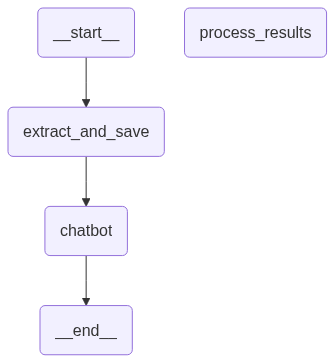

In [15]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [16]:
from datetime import datetime, timedelta

def extract_user_and_message(raw_message: str) -> tuple[str, str]:
    return [value.strip() for value in raw_message.split(":")]

last_invoked = datetime.now()

async def handle_message_with_graph(raw_message, history):
    user, message = extract_user_and_message(raw_message)
    print(f"Extracted user: {user}")
    print(f"Extracted message: {message}")
    last_invoked = datetime.now()
    events = await graph.ainvoke({"messages": [{"role": "user", "content": raw_message}], "input": message, "who": user, "extracted": False, "is_init": False, "ask_host_intervention": False, "is_nudge": False},
    config={"configurable": {"thread_id": 1}})
    print("This is the history: ")
    print(history)
    print("events: ")
    print(events)
    print("printing events: ")
    for event in events["messages"]:
        print("event: ")
        print(event)
    return events["messages"][-1].content

In [ ]:
nudge_prompt = "There has been no activity for a while now. Please send a message prompting the users in the group to respond and take action."

nudge_counter = 0

async def nudge():
    global last_invoked
    global nudge_prompt
    global nudge_counter
    global graph
    if (datetime.now() - last_invoked) > timedelta(seconds=150):
        try:
            print("Yay here!")
            ask_host_intervention = False if nudge_counter < 3 else True
            nudge_counter += 1
            last_invoked = datetime.now()
            events = await graph.ainvoke({"messages": [{"role": "user", "content": nudge_prompt}], "input": nudge_prompt, "who": "system", "extracted": False, "is_init": False, "ask_host_intervention": ask_host_intervention, "is_nudge": True},
            config={"configurable": {"thread_id": 1}})
            print("Message from bot: ")
            print(events["messages"][-1].content)
        except Exception as e:
            print("Outer except: ")
            print(e)
    else:
        print("else block executed")
        print(last_invoked)
        print(datetime.now() - last_invoked)
        print(timedelta(seconds=150))
    Timer(5.0, nudge)

Timer(5.0, nudge)


else block executed
2025-06-18 16:45:08.433626
0:00:37.765626
0:02:30
else block executed
2025-06-18 16:45:08.433626
0:00:42.767583
0:02:30
else block executed
2025-06-18 16:45:08.433626
0:02:22.801164
0:02:30
else block executed
2025-06-18 16:45:08.433626
0:02:27.803878
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:02.742213
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:07.744311
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:12.747667
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:17.748950
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:22.957856
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:28.118026
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:00:33.121205
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:01:35.710571
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:01:40.713218
0:02:30
else block executed
2025-06-18 16:47:38.497921
0:01:45.715955
0:02:30
else block executed


In [ ]:
import gradio as gr

present_info, missing_info = render_initial_data_with_priorities(host_inputs, key_priorites)

init_prompt_system = f"""
    You are the world's best travel agent who has information about all the hotels in the world.
                
    Today your goal is to help a group of users choose the right hotel for their needs.
    The entire group wants to travel together and stay at the same hotel.
    
    However, you need certain information from the users to do so.
    This includes destination, number of adults, number of children, number of rooms, start date of trip, end date of trip, amenities required, required bed types, whether or not free breakfast should be included (free_breakfast), what the budget range is as well (max_price and min_price).

    Here's the information you already have:
    {present_info}

    The information you need to make recommendations will be provided next as input. 

    You need to obtain this information with the smallest amount of questions and as quick as possible without appearing like a robot or a form.

    Construct a message to initiate the conversation and start collecting this information in the most human way possible.
"""

init_prompt_user = f"""
    Here's the information you need to collect.
    {missing_info}
"""

last_invoked = datetime.now() 
init_message = await graph.ainvoke({"messages": [{"role": "system", "content": init_prompt_system}, {"role": "user", "content": init_prompt_user}],
                                    "users": {
        "joseph": host_inputs,
        "user2": HotelSearchRequirements()
    },
    "input": init_prompt_user, "who": "system", "is_init": True, "extracted": False, "host": "joseph", "ask_host_intervention": False, "is_nudge": False, **host_inputs.model_dump()}, config={"configurable": {"thread_id": 1}})

print("init_message")
print(init_message["messages"][-1].content)

def get_init_message():
    return [{"role": "system", "content": init_message["messages"][-1].content}]

gr.ChatInterface(
    fn=handle_message_with_graph, 
    type="messages",
    chatbot=gr.Chatbot(value=get_init_message, every=gr.Timer(1), type="messages")
).launch()

/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here's the string being returned for available information: 

num_adults: 3
num_children: 0
num_rooms: 2
free_cancelation: Yes
Here's the string being returned for missing information: 

            destination: The destination where to look for hotels. N/A if empty
            
            from_date: Start date of trip. N/A if empty
            
            to_date: End date of trip. This is the date till which they want to book the hotel. N/A if empty
            
            amenities: Amenities required.
            
            free_breakfast: Is free breakfast required? N/A if empty. Yes if free breakfast is required and No if free breakfast is not needed.
            
            max_price: What is the max budget? -1 if empty
            
partially_missing_data: 

prompt being executed: 

                    You are the world's best travel agent who has information about all the hotels in the world.

                    Today your goal is to help a group of users choose the righ

Extracted user: joseph
Extracted message: I think we should go to Amsterdam!
extract_and_Save called!
state received: 
{'messages': [SystemMessage(content="\n    You are the world's best travel agent who has information about all the hotels in the world.\n\n    Today your goal is to help a group of users choose the right hotel for their needs.\n    The entire group wants to travel together and stay at the same hotel.\n\n    However, you need certain information from the users to do so.\n    This includes destination, number of adults, number of children, number of rooms, start date of trip, end date of trip, amenities required, required bed types, whether or not free breakfast should be included (free_breakfast), what the budget range is as well (max_price and min_price).\n\n    Here's the information you already have:\n    \nnum_adults: 3\nnum_children: 0\nnum_rooms: 2\nfree_cancelation: Yes\n\n    The information you need to make recommendations will be provided next as input. \n\n  